# Gradiente descendente do zero

**Tema:** Álgebra Linear e Otimização › Cálculo e Gradiente Descendente

Este notebook implementa gradiente descendente batch, estocástico, com
momentum e com Adam — todos do zero, em NumPy puro — e usa cada um para
ajustar uma regressão. A meta é ver, com os próprios olhos, o que cada
variante corrige na anterior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Gradiente descendente numa função simples, com trajetória visível

$f(x, y) = x^2 + 3y^2$ — uma tigela alongada, fácil de visualizar em contorno.

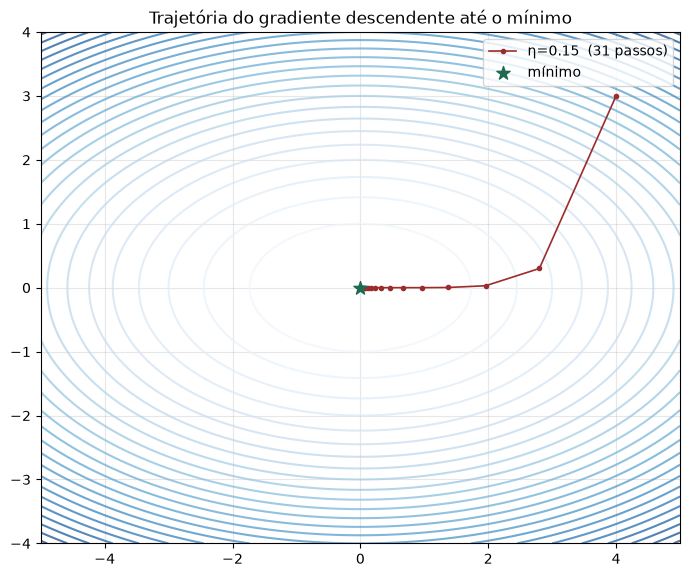

In [2]:
def f(v):
    x, y = v
    return x**2 + 3 * y**2


def grad_f(v):
    x, y = v
    return np.array([2 * x, 6 * y])


def gradiente_descendente(grad_fn, v0, eta, n_iter=50):
    v = v0.copy()
    trajetoria = [v.copy()]
    for _ in range(n_iter):
        v = v - eta * grad_fn(v)
        trajetoria.append(v.copy())
    return np.array(trajetoria)


v0 = np.array([4.0, 3.0])
traj_boa = gradiente_descendente(grad_f, v0, eta=0.15, n_iter=30)

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
zz = xx**2 + 3 * yy**2

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(xx, yy, zz, levels=25, cmap="Blues", alpha=0.7)
ax.plot(traj_boa[:, 0], traj_boa[:, 1], "o-", color=VERMELHO, ms=3, lw=1.2,
        label=f"η=0.15  ({len(traj_boa)} passos)")
ax.scatter([0], [0], color=VERDE, s=100, marker="*", zorder=5, label="mínimo")
ax.set_title("Trajetória do gradiente descendente até o mínimo")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 2. O efeito da taxa de aprendizado: pequena, boa e grande demais

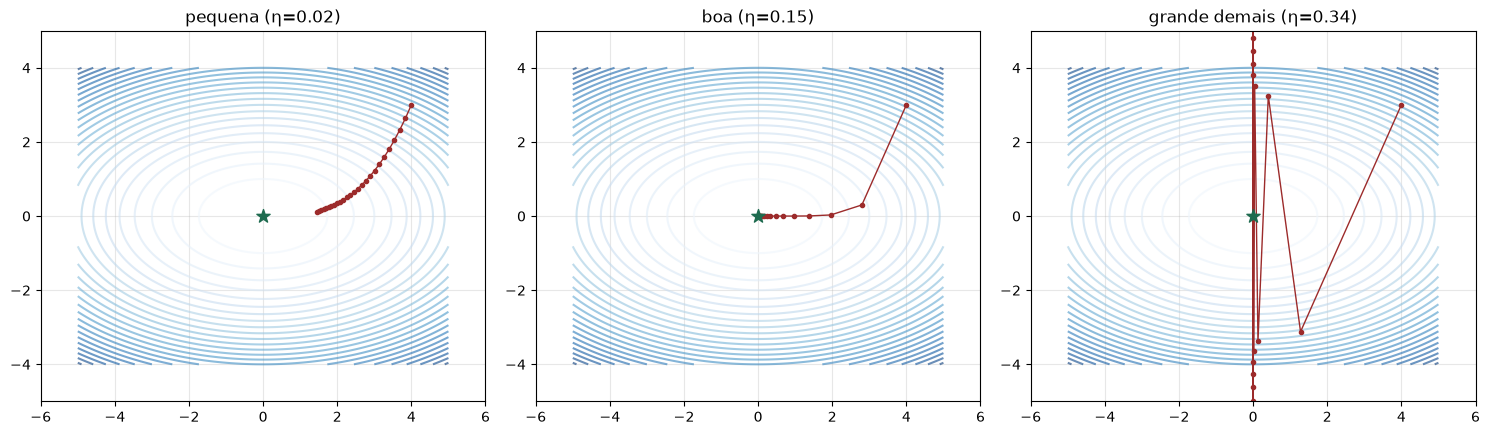

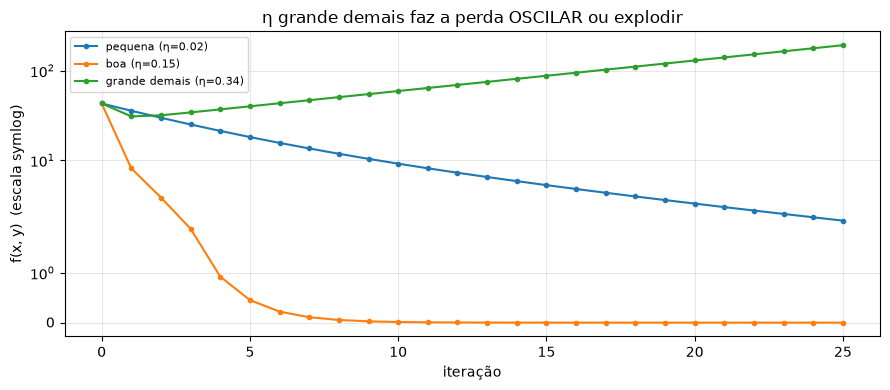

In [3]:
etas = {"pequena (η=0.02)": 0.02, "boa (η=0.15)": 0.15,
        "grande demais (η=0.34)": 0.34}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nome, eta) in zip(axes, etas.items()):
    traj = gradiente_descendente(grad_f, v0, eta=eta, n_iter=25)
    ax.contour(xx, yy, zz, levels=25, cmap="Blues", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "o-", color=VERMELHO, ms=3, lw=1)
    ax.scatter([0], [0], color=VERDE, s=100, marker="*", zorder=5)
    ax.set_title(nome)
    ax.set_xlim(-6, 6); ax.set_ylim(-5, 5); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for nome, eta in etas.items():
    traj = gradiente_descendente(grad_f, v0, eta=eta, n_iter=25)
    perdas = [f(v) for v in traj]
    ax.plot(perdas, "o-", ms=3, label=nome)
ax.set_yscale("symlog")
ax.set_xlabel("iteração"); ax.set_ylabel("f(x, y)  (escala symlog)")
ax.set_title("η grande demais faz a perda OSCILAR ou explodir")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Aplicando a uma regressão linear real: gradiente descendente batch

beta verdadeiro   : [ 2.  -1.5  0.8]
beta via GD       : [ 2.0357 -1.4854  0.8201]
beta via lstsq    : [ 2.0357 -1.4854  0.8201]

MSE final (GD)    : 0.264018


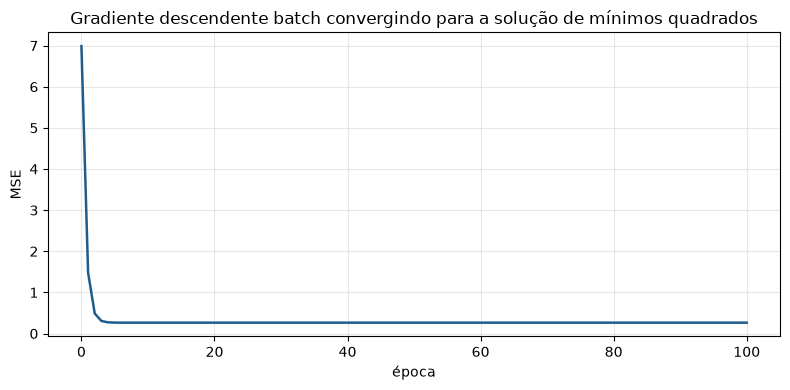

In [4]:
n, p = 400, 3
X = rng.normal(0, 1, (n, p))
beta_real = np.array([2.0, -1.5, 0.8])
y = X @ beta_real + rng.normal(0, 0.5, n)


def perda_mse(beta, X, y):
    residuo = X @ beta - y
    return np.mean(residuo ** 2)


def grad_mse(beta, X, y):
    residuo = X @ beta - y
    return (2 / len(y)) * X.T @ residuo


def gd_batch(X, y, eta, n_epocas):
    beta = np.zeros(X.shape[1])
    historico = [perda_mse(beta, X, y)]
    for _ in range(n_epocas):
        beta = beta - eta * grad_mse(beta, X, y)
        historico.append(perda_mse(beta, X, y))
    return beta, historico


beta_gd, hist_gd = gd_batch(X, y, eta=0.3, n_epocas=100)
beta_referencia = np.linalg.lstsq(X, y, rcond=None)[0]

print(f"beta verdadeiro   : {beta_real}")
print(f"beta via GD       : {beta_gd}")
print(f"beta via lstsq    : {beta_referencia}")
print(f"\nMSE final (GD)    : {hist_gd[-1]:.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_gd, color=AZUL, lw=1.8)
ax.set_xlabel("época"); ax.set_ylabel("MSE")
ax.set_title("Gradiente descendente batch convergindo para a solução de mínimos quadrados")
plt.tight_layout(); plt.show()

## 4. SGD: gradiente ruidoso, muito mais barato por passo

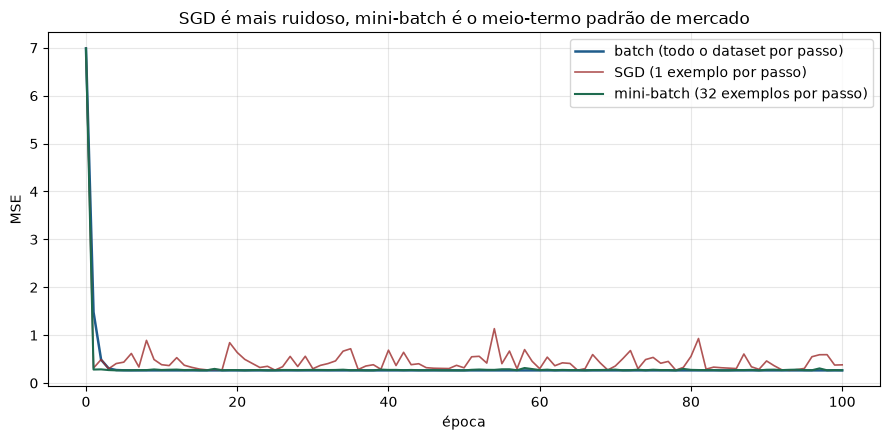

MSE final — batch: 0.26402  SGD: 0.38022  mini-batch: 0.26815


In [5]:
def gd_estocastico(X, y, eta, n_epocas, tamanho_lote=1, seed=0):
    rng_local = np.random.default_rng(seed)
    n = len(y)
    beta = np.zeros(X.shape[1])
    historico = [perda_mse(beta, X, y)]
    for _ in range(n_epocas):
        indices = rng_local.permutation(n)
        for inicio in range(0, n, tamanho_lote):
            idx = indices[inicio:inicio + tamanho_lote]
            beta = beta - eta * grad_mse(beta, X[idx], y[idx])
        historico.append(perda_mse(beta, X, y))
    return beta, historico


beta_sgd, hist_sgd = gd_estocastico(X, y, eta=0.1, n_epocas=100, tamanho_lote=1)
beta_mb, hist_mb = gd_estocastico(X, y, eta=0.2, n_epocas=100, tamanho_lote=32)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_gd, color=AZUL, lw=1.8, label="batch (todo o dataset por passo)")
ax.plot(hist_sgd, color=VERMELHO, lw=1.2, alpha=0.8, label="SGD (1 exemplo por passo)")
ax.plot(hist_mb, color=VERDE, lw=1.5, label="mini-batch (32 exemplos por passo)")
ax.set_xlabel("época"); ax.set_ylabel("MSE")
ax.set_title("SGD é mais ruidoso, mini-batch é o meio-termo padrão de mercado")
ax.legend(); plt.tight_layout(); plt.show()

print(f"MSE final — batch: {hist_gd[-1]:.5f}  SGD: {hist_sgd[-1]:.5f}  "
      f"mini-batch: {hist_mb[-1]:.5f}")

## 5. Momentum: suavizando o ziguezague

Numa função mal condicionada (elipse alongada), o gradiente descendente puro
oscila entre as paredes do vale. Momentum acumula uma média das direções
recentes e reduz esse ziguezague.

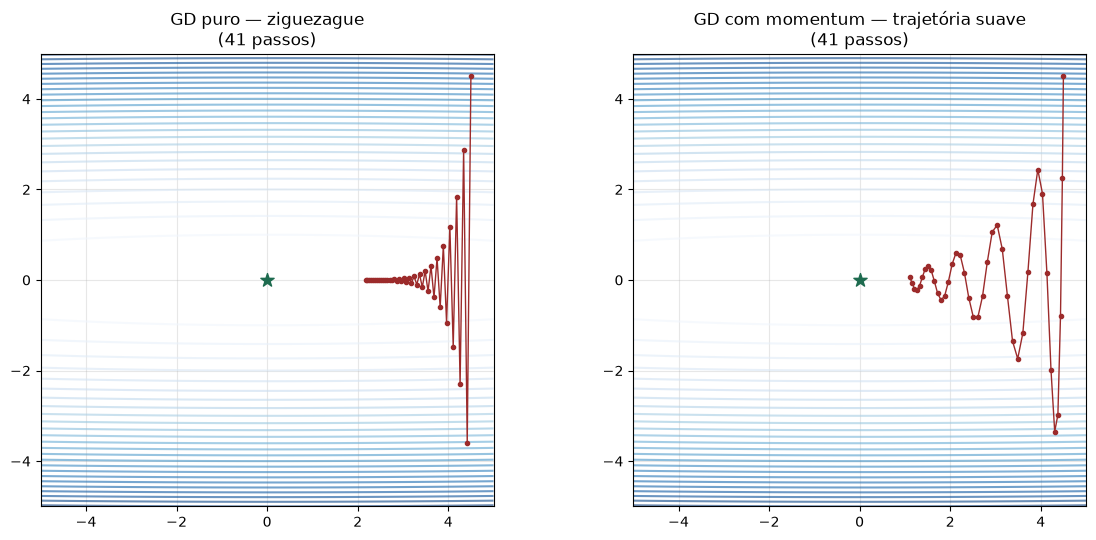

distância até o mínimo após 40 passos:
  GD puro       : 2.1761
  GD c/ momentum: 1.1083


In [6]:
def f_mal_condicionada(v):
    x, y = v
    return 0.05 * x**2 + 5 * y**2


def grad_mal_condicionada(v):
    x, y = v
    return np.array([0.1 * x, 10 * y])


def gd_com_momentum(grad_fn, v0, eta, mu, n_iter):
    v = v0.copy()
    velocidade = np.zeros_like(v)
    trajetoria = [v.copy()]
    for _ in range(n_iter):
        velocidade = mu * velocidade + grad_fn(v)
        v = v - eta * velocidade
        trajetoria.append(v.copy())
    return np.array(trajetoria)


v0_mal = np.array([4.5, 4.5])
traj_sem_momentum = gradiente_descendente(grad_mal_condicionada, v0_mal, eta=0.18, n_iter=40)
traj_com_momentum = gd_com_momentum(grad_mal_condicionada, v0_mal, eta=0.05, mu=0.85, n_iter=40)

xx2, yy2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
zz2 = 0.05 * xx2**2 + 5 * yy2**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, traj, nome in [(axes[0], traj_sem_momentum, "GD puro — ziguezague"),
                       (axes[1], traj_com_momentum, "GD com momentum — trajetória suave")]:
    ax.contour(xx2, yy2, zz2, levels=25, cmap="Blues", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "o-", color=VERMELHO, ms=3, lw=1)
    ax.scatter([0], [0], color=VERDE, s=100, marker="*", zorder=5)
    ax.set_title(f"{nome}\n({len(traj)} passos)")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"distância até o mínimo após 40 passos:")
print(f"  GD puro       : {np.linalg.norm(traj_sem_momentum[-1]):.4f}")
print(f"  GD c/ momentum: {np.linalg.norm(traj_com_momentum[-1]):.4f}")

## 6. Adam: taxa adaptativa por parâmetro

Implementação direta da fórmula do material teórico — momentum de primeira
ordem ($m$) e de segunda ordem ($v$), com correção de viés.

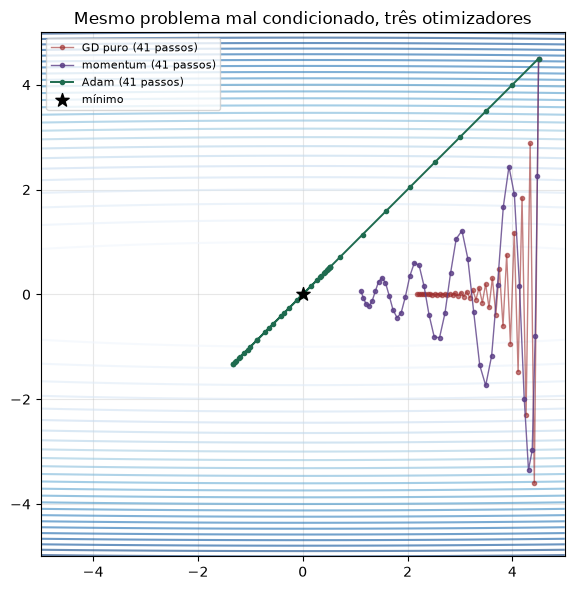

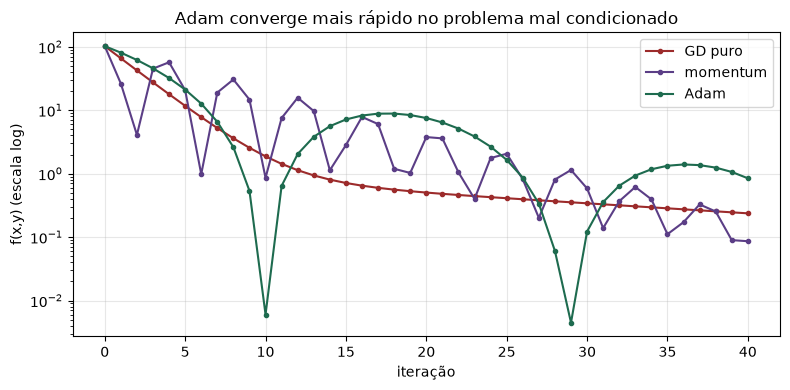

In [7]:
def adam(grad_fn, v0, eta=0.5, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=40):
    x = v0.copy()
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    trajetoria = [x.copy()]
    for t in range(1, n_iter + 1):
        g = grad_fn(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_corrigido = m / (1 - beta1**t)
        v_corrigido = v / (1 - beta2**t)
        x = x - eta * m_corrigido / (np.sqrt(v_corrigido) + eps)
        trajetoria.append(x.copy())
    return np.array(trajetoria)


traj_adam = adam(grad_mal_condicionada, v0_mal, eta=0.5, n_iter=40)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(xx2, yy2, zz2, levels=25, cmap="Blues", alpha=0.6)
ax.plot(traj_sem_momentum[:, 0], traj_sem_momentum[:, 1], "o-", color=VERMELHO,
        ms=3, lw=1, alpha=0.6, label=f"GD puro ({len(traj_sem_momentum)} passos)")
ax.plot(traj_com_momentum[:, 0], traj_com_momentum[:, 1], "o-", color=ROXO,
        ms=3, lw=1, alpha=0.8, label=f"momentum ({len(traj_com_momentum)} passos)")
ax.plot(traj_adam[:, 0], traj_adam[:, 1], "o-", color=VERDE,
        ms=3, lw=1.4, label=f"Adam ({len(traj_adam)} passos)")
ax.scatter([0], [0], color="black", s=100, marker="*", zorder=5, label="mínimo")
ax.set_aspect("equal"); ax.legend(fontsize=8)
ax.set_title("Mesmo problema mal condicionado, três otimizadores")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for traj, nome, cor in [(traj_sem_momentum, "GD puro", VERMELHO),
                        (traj_com_momentum, "momentum", ROXO),
                        (traj_adam, "Adam", VERDE)]:
    perdas = [f_mal_condicionada(v) for v in traj]
    ax.semilogy(perdas, "o-", ms=3, color=cor, label=nome)
ax.set_xlabel("iteração"); ax.set_ylabel("f(x,y) (escala log)")
ax.set_title("Adam converge mais rápido no problema mal condicionado")
ax.legend(); plt.tight_layout(); plt.show()

## O que levar deste notebook

- Gradiente descendente é: calcule o gradiente, dê um passo contra ele,
  repita — e a taxa de aprendizado decide se isso converge suave, devagar ou
  explode.
- SGD troca o gradiente exato por uma estimativa ruidosa e muito mais barata;
  mini-batch é o equilíbrio que a prática de mercado usa quase sempre.
- Momentum acumula direções passadas e reduz o ziguezague em problemas mal
  condicionados.
- Adam combina momentum com uma taxa de aprendizado adaptativa por
  parâmetro, e costuma convergir mais rápido em problemas difíceis, com menos
  necessidade de ajuste fino de $\eta$.
- Em todos os casos, o **condicionamento** do problema (o próximo notebook
  formaliza isso) determina o quão difícil é a tarefa, independentemente do
  otimizador escolhido.

→ Próximo: **Convexidade e condicionamento**, onde a Hessiana explica por que
alguns problemas são fáceis e outros são teimosos.